In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 



In [25]:
df = pd.read_csv("../data/wallet_features.csv")

df.shape

(9540, 29)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   address                         9540 non-null   object 
 1   fraud_flag                      9540 non-null   int64  
 2   transactions_sent               9540 non-null   int64  
 3   transactions_received           9540 non-null   int64  
 4   total_transactions              9540 non-null   int64  
 5   unique_receivers                9540 non-null   int64  
 6   unique_senders                  9540 non-null   int64  
 7   total_eth_sent                  9540 non-null   float64
 8   total_eth_received              9540 non-null   float64
 9   avg_eth_sent                    9540 non-null   float64
 10  avg_eth_received                9540 non-null   float64
 11  max_eth_sent                    9540 non-null   float64
 12  max_eth_received                95

In [27]:
df.head()

,address,fraud_flag,transactions_sent,transactions_received,total_transactions,unique_receivers,unique_senders,total_eth_sent,total_eth_received,avg_eth_sent,...,token_transfers_received,total_token_transfers,unique_tokens_sent,unique_tokens_received,unique_tokens_interacted,unique_token_receivers,unique_token_senders,token_active_days,token_activity_lifetime_days,token_transfers_per_active_day
0,0x8aa31705fa6f0a7801e8d881ba4c47de23d2652a,0,21,10,31,14,9,63.277477,63.284357,3.013213,...,0,0,0,0,0,0,0,0,0,NaN
1,0x4911487b52134454384d33875dfd7d22e2c5d783,0,22,23,45,21,7,70.638454,70.647694,3.210839,...,0,0,0,0,0,0,0,0,0,NaN
2,0x2497ecd2ec7dd88e41dff727c0b6f14a85956993,0,43,44,87,43,6,6.471600,6.494585,0.150502,...,0,0,0,0,0,0,0,0,0,NaN
3,0xc4fbde4c51b306e3f3e1ae55a5a888be58fcfd00,0,19,12,31,14,11,8.108358,8.113994,0.426756,...,0,0,0,0,0,0,0,0,0,NaN
4,0xbb90125091fd7c7953fb98b59f6ce75e2500e5db,1,15,14,29,15,12,30.124728,27.128942,2.008315,...,0,0,0,0,0,0,0,0,0,NaN


In [28]:
df.isna().sum().sort_values(ascending=False)

token_transfers_per_active_day    4893
transactions_per_active_day        257
active_days                          0
token_activity_lifetime_days         0
token_active_days                    0
unique_token_senders                 0
unique_token_receivers               0
unique_tokens_interacted             0
unique_tokens_received               0
unique_tokens_sent                   0
total_token_transfers                0
token_transfers_received             0
token_transfers_sent                 0
wallet_lifetime_days                 0
address                              0
fraud_flag                           0
avg_gas_limit                        0
max_eth_received                     0
max_eth_sent                         0
avg_eth_received                     0
avg_eth_sent                         0
total_eth_received                   0
total_eth_sent                       0
unique_senders                       0
unique_receivers                     0
total_transactions       

In [29]:
df["has_transaction_activity"] = (
    df["total_transactions"] > 0
).astype(int)

df["has_token_activity"] = (
    df["total_token_transfers"] > 0
).astype(int)

In [30]:
df["transactions_per_active_day"] = (
    df["transactions_per_active_day"].fillna(0)
)

df["token_transfers_per_active_day"] = (
    df["token_transfers_per_active_day"].fillna(0)
)

In [31]:
df.isna().sum().sum()

np.int64(0)

In [32]:
df.shape

(9540, 31)

In [33]:
df["fraud_flag"].value_counts()

fraud_flag
0    7637
1    1903
Name: count, dtype: int64

In [34]:
df["fraud_flag"].value_counts(normalize=True) * 100

fraud_flag
0    80.052411
1    19.947589
Name: proportion, dtype: float64

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fraud_flag,9540.0,1.994759e-01,3.996273e-01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
transactions_sent,9540.0,3.602099e+03,1.624292e+05,0.0,1.000000e+00,3.000000e+00,1.200000e+01,1.537887e+07
transactions_received,9540.0,3.570474e+03,1.262725e+05,0.0,2.000000e+00,5.000000e+00,2.900000e+01,1.148758e+07
total_transactions,9540.0,7.171102e+03,2.073978e+05,0.0,4.000000e+00,9.000000e+00,5.900000e+01,1.537910e+07
unique_receivers,9540.0,4.252251e+02,1.023102e+04,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.938910e+05
unique_senders,9540.0,5.759073e+02,2.128919e+04,0.0,1.000000e+00,2.000000e+00,6.000000e+00,1.908701e+06
total_eth_sent,9540.0,4.242102e+04,1.652071e+06,0.0,5.027781e-01,1.545703e+01,1.009990e+02,1.355047e+08
total_eth_received,9540.0,4.412125e+04,1.305447e+06,0.0,3.723749e+00,3.450855e+01,1.010000e+02,8.415729e+07
avg_eth_sent,9540.0,4.382601e+01,2.120690e+02,0.0,1.380725e-01,1.810838e+00,2.473490e+01,1.016267e+04
avg_eth_received,9540.0,7.572752e+01,6.311258e+02,0.0,4.996067e-01,1.900000e+00,2.473937e+01,5.021495e+04


In [36]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

skewness = (
    df[numeric_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness

unique_tokens_sent                94.960437
unique_tokens_received            92.964899
unique_tokens_interacted          92.892438
transactions_sent                 89.394890
transactions_received             80.357382
unique_senders                    78.460793
total_eth_sent                    66.440734
max_eth_sent                      64.518429
total_transactions                61.260745
avg_eth_received                  55.880250
token_transfers_received          52.364905
transactions_per_active_day       48.015373
unique_token_receivers            46.052048
total_eth_received                45.997071
total_token_transfers             45.630279
unique_token_senders              44.834614
token_transfers_sent              42.857940
unique_receivers                  41.425243
token_transfers_per_active_day    39.738710
max_eth_received                  39.572409
avg_eth_sent                      21.578602
token_active_days                 13.851872
avg_gas_limit                   

In [37]:
comparison_cols = [
    "total_transactions",
    "transactions_per_active_day",
    "unique_receivers",
    "unique_senders",
    "wallet_lifetime_days",
    "total_token_transfers",
    "unique_tokens_interacted",
    "token_active_days"
]

median_comparison = (
    df.groupby("fraud_flag")[comparison_cols]
    .median()
    .T
)

median_comparison

fraud_flag,0,1
total_transactions,11.0,6.0
transactions_per_active_day,2.0,1.8
unique_receivers,2.0,1.0
unique_senders,2.0,4.0
wallet_lifetime_days,92.0,10.0
total_token_transfers,0.0,1.0
unique_tokens_interacted,0.0,1.0
token_active_days,0.0,1.0


In [38]:
mean_comparison = (
    df.groupby("fraud_flag")[comparison_cols]
    .mean()
    .T
)

mean_comparison

fraud_flag,0,1
total_transactions,8939.904544,72.656332
transactions_per_active_day,12.035900,3.991911
unique_receivers,530.204792,3.926957
unique_senders,715.462485,15.853389
wallet_lifetime_days,249.910305,63.323699
total_token_transfers,1456.496923,6.767210
unique_tokens_interacted,7.633102,3.342091
token_active_days,11.587796,2.658434


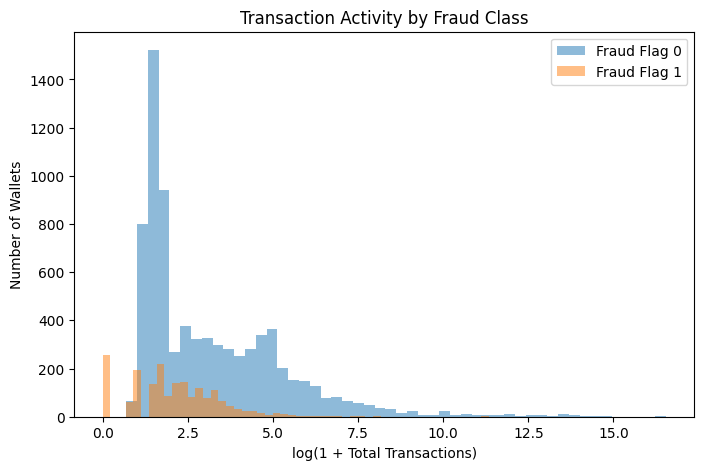

In [39]:
plt.figure(figsize=(8, 5))

for fraud_flag in [0, 1]:
    values = np.log1p(
        df.loc[
            df["fraud_flag"] == fraud_flag,
            "total_transactions"
        ]
    )

    plt.hist(
        values,
        bins=50,
        alpha=0.5,
        label=f"Fraud Flag {fraud_flag}"
    )

plt.xlabel("log(1 + Total Transactions)")
plt.ylabel("Number of Wallets")
plt.title("Transaction Activity by Fraud Class")
plt.legend()
plt.show()

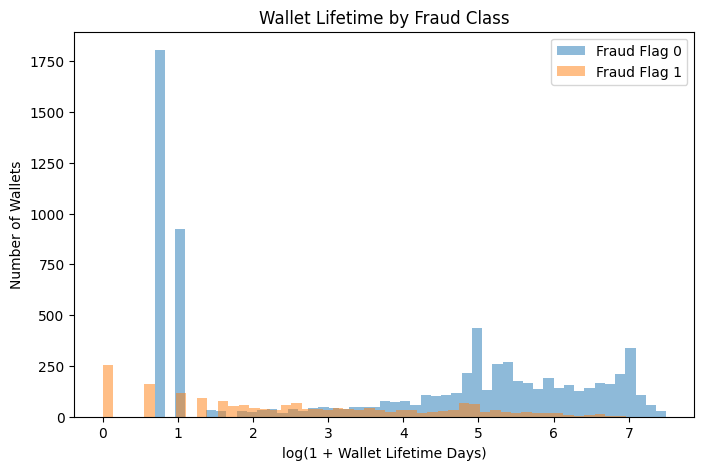

In [40]:
plt.figure(figsize=(8, 5))

for fraud_flag in [0, 1]:
    values = np.log1p(
        df.loc[
            df["fraud_flag"] == fraud_flag,
            "wallet_lifetime_days"
        ]
    )

    plt.hist(
        values,
        bins=50,
        alpha=0.5,
        label=f"Fraud Flag {fraud_flag}"
    )

plt.xlabel("log(1 + Wallet Lifetime Days)")
plt.ylabel("Number of Wallets")
plt.title("Wallet Lifetime by Fraud Class")
plt.legend()
plt.show()

In [41]:
log_features = [
    "transactions_sent",
    "transactions_received",
    "total_transactions",
    "unique_receivers",
    "unique_senders",

    "total_eth_sent",
    "total_eth_received",
    "avg_eth_sent",
    "avg_eth_received",
    "max_eth_sent",
    "max_eth_received",

    "active_days",
    "wallet_lifetime_days",

    "token_transfers_sent",
    "token_transfers_received",
    "total_token_transfers",

    "unique_tokens_sent",
    "unique_tokens_received",
    "unique_tokens_interacted",
    "unique_token_receivers",
    "unique_token_senders",

    "token_active_days",
    "token_activity_lifetime_days"
]

for col in log_features:
    df[f"log_{col}"] = np.log1p(df[col])

In [42]:
df.shape

(9540, 54)

In [43]:
corr = df.drop(columns=["address"]).corr(numeric_only=True)

In [44]:
fraud_corr = (
    corr["fraud_flag"]
    .drop("fraud_flag")
    .sort_values(key=abs, ascending=False)
)

fraud_corr

log_total_eth_received             -0.365144
has_transaction_activity           -0.333322
log_avg_eth_received               -0.327909
log_max_eth_received               -0.318146
log_total_eth_sent                 -0.276323
log_active_days                    -0.251780
log_max_eth_sent                   -0.234857
has_token_activity                  0.228831
log_transactions_sent              -0.227729
wallet_lifetime_days               -0.220337
log_total_transactions             -0.215324
log_wallet_lifetime_days           -0.188559
log_avg_eth_sent                   -0.179224
active_days                        -0.150722
log_transactions_received          -0.148377
log_unique_receivers               -0.147345
avg_gas_limit                      -0.145506
token_activity_lifetime_days       -0.113653
log_unique_token_receivers         -0.109161
log_token_transfers_sent           -0.100439
log_unique_tokens_sent             -0.089117
avg_gas_price                       0.070011
token_acti

In [45]:
feature_corr = (
    df.drop(columns=["address", "fraud_flag"])
    .corr(numeric_only=True)
    .abs()
)

upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = [
    (column, index, upper_triangle.loc[index, column])
    for column in upper_triangle.columns
    for index in upper_triangle.index
    if upper_triangle.loc[index, column] > 0.90
]

high_corr_pairs

[('max_eth_sent', 'total_eth_sent', np.float64(0.9477230068910462)),
 ('transactions_per_active_day',
  'total_transactions',
  np.float64(0.9464428851840425)),
 ('token_transfers_received',
  'token_transfers_sent',
  np.float64(0.9648168125707456)),
 ('total_token_transfers',
  'token_transfers_sent',
  np.float64(0.9949267232195019)),
 ('total_token_transfers',
  'token_transfers_received',
  np.float64(0.986372681494001)),
 ('unique_tokens_sent',
  'transactions_received',
  np.float64(0.9261545920406524)),
 ('unique_tokens_received',
  'transactions_received',
  np.float64(0.9320786886411478)),
 ('unique_tokens_received',
  'unique_tokens_sent',
  np.float64(0.9948288728456471)),
 ('unique_tokens_interacted',
  'transactions_received',
  np.float64(0.931961217917509)),
 ('unique_tokens_interacted',
  'unique_tokens_sent',
  np.float64(0.994791415654256)),
 ('unique_tokens_interacted',
  'unique_tokens_received',
  np.float64(0.9999944529645801)),
 ('unique_token_senders',
  'token

In [46]:
model_features = [
    # Activity indicators
    "has_transaction_activity",
    "has_token_activity",

    # Transaction behaviour
    "log_total_transactions",
    "log_unique_receivers",
    "log_unique_senders",

    # ETH behaviour
    "log_total_eth_sent",
    "log_total_eth_received",
    "log_avg_eth_sent",
    "log_avg_eth_received",

    # Time/activity behaviour
    "log_active_days",
    "log_wallet_lifetime_days",
    "transactions_per_active_day",

    # Gas behaviour
    "avg_gas_limit",
    "avg_gas_price",

    # Token behaviour
    "log_total_token_transfers",
    "log_unique_token_receivers",
    "log_token_activity_lifetime_days",
    "token_transfers_per_active_day"
]

In [47]:
selected_corr = (
    df[model_features]
    .corr()
    .abs()
)

upper = selected_corr.where(
    np.triu(
        np.ones(selected_corr.shape),
        k=1
    ).astype(bool)
)

remaining_high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.90
]

remaining_high_corr

[('log_active_days', 'log_total_transactions', np.float64(0.9235024571067894))]

In [53]:
model_features.remove("log_active_days")

In [54]:
model_df = df[
    ["address", "fraud_flag"] + model_features
].copy()

model_df.shape

(9540, 19)

In [55]:
model_df.isna().sum().sum()

np.int64(0)

In [56]:
model_df.duplicated(subset="address").sum()

np.int64(0)

In [57]:
model_df["fraud_flag"].value_counts()

fraud_flag
0    7637
1    1903
Name: count, dtype: int64

In [58]:
model_df.dtypes

address                              object
fraud_flag                            int64
has_transaction_activity              int64
has_token_activity                    int64
log_total_transactions              float64
log_unique_receivers                float64
log_unique_senders                  float64
log_total_eth_sent                  float64
log_total_eth_received              float64
log_avg_eth_sent                    float64
log_avg_eth_received                float64
log_wallet_lifetime_days            float64
transactions_per_active_day         float64
avg_gas_limit                       float64
avg_gas_price                       float64
log_total_token_transfers           float64
log_unique_token_receivers          float64
log_token_activity_lifetime_days    float64
token_transfers_per_active_day      float64
dtype: object

In [60]:
model_df.to_csv(
    "../data/wallet_features_processed.csv",
    index=False
)